In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

ACTIVATIONS_ROOT = './activations/'
DATASET_ROOT = './datasets'

label_fontsize = 18

In [2]:
import torch

use_cuda = torch.cuda.is_available()
use_mps = torch.backends.mps.is_available() and False

if use_cuda:
    device = torch.device("cuda")
elif use_mps:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='cuda')

In [3]:
from src.data_utils import get_cifar10
from src.model_utils import get_activations
from src.spectral_cka import experiment

In [4]:
def preprocess_activations(activations):
    activations = torch.tensor(activations)
    activations = activations.to(torch.float64)
    activations = activations.view(activations.size(0), -1)
    print(activations.size())
    # subtract mean
    activations = activations - activations.mean(dim=0, keepdim=True)
    return activations

### ResNet18 - CIFAR10 example


In [5]:
imgs = get_cifar10(DATASET_ROOT)
print(imgs.shape)

model_name = 'resnet18'
pretrained = True
acts = get_activations(model_name, imgs, pretrained=pretrained,
                       dataset_name='cifar10', device=device,
                       activations_root=ACTIVATIONS_ROOT)
acts.keys()

torch.Size([10000, 3, 32, 32])
Loading activations from file ./activations/cifar10/resnet18_pretrained_cifar10.npz


dict_keys(['act1', 'layer1', 'layer2', 'layer3', 'layer4'])

torch.Size([10000, 25088])
File ./results/overlap_resnet18_layer4_unbiased_2000_trials_3_iters_20.npz exists. Skipping...


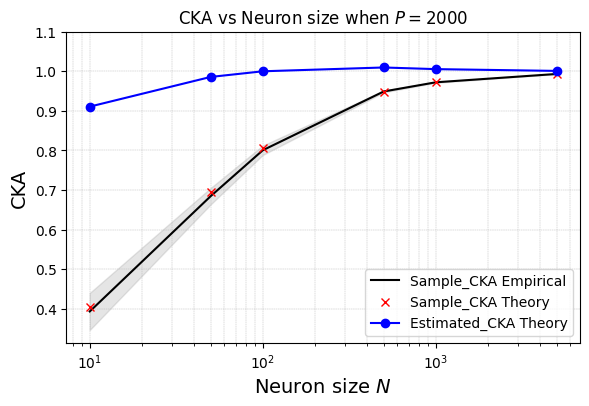

dict_keys(['true_cka', 'true_cca', 'eigs_mean', 'eigs_std', 'Q_th_mean', 'Q_th_std', 'Q_emp_mean', 'Q_emp_std', 'M_emp_mean', 'M_emp_std', 'M_pred_mean', 'M_pred_std', 'M_tilde_pred_mean', 'M_tilde_pred_std', 'cka_naive_mean', 'cka_naive_std', 'cka_pred_mean', 'cka_pred_std', 'cka_est_mean', 'cka_est_std', 'cca_naive_mean', 'cca_naive_std', 'cca_pred_mean', 'cca_pred_std', 'cca_est_mean', 'cca_est_std', 'moment_cka_est_mean', 'moment_cka_est_std', 'M_pred_final', 'Q_th_final', 'eig_ratio_final', 'naive_cka_final', 'predicted_cka_final', 'estimated_cka_final', 'naive_cca_final', 'predicted_cca_final', 'estimated_cca_final', 'M_tilde_pred_final', 'M_tilde'])


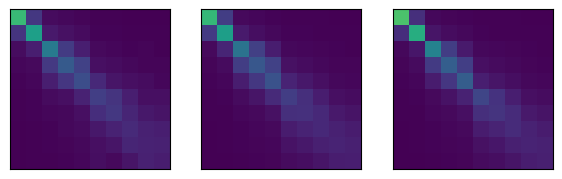

In [6]:
sample_sizes = np.arange(1, 2)*2000
neuron_sizes = np.array([10, 50, 100, 500, 1000, 5000])
num_trials = 3
num_iterations = 20
cutoff = 200

use_real_neuron = False
override = False

layer_name = 'layer4'

act = acts[layer_name]
act = preprocess_activations(act).to(device)

all_data = experiment(act,
                      act,
                      sample_sizes,
                      neuron_sizes,
                      num_trials=num_trials,
                      num_iterations=num_iterations,
                      cutoff=cutoff,
                      use_real_neuron=use_real_neuron,
                      fn_prefix=f'overlap_resnet18_{layer_name}_unbiased',
                      fn_suffix='',
                      override=override)


print(all_data[0].keys())

Q_emp_mean = all_data[0]['Q_emp_mean'].mean(-1)
Q_th_mean = all_data[0]['Q_th_mean'].mean(-1)
Q_th_avg = all_data[0]['Q_th_final'].mean(-1)

fig, axs = plt.subplots(1, 3, figsize=(7, 5))

N_idx = 2

axs[0].imshow(Q_emp_mean[N_idx, :10, :10], vmin=0, vmax=1, cmap='viridis')
axs[1].imshow(Q_th_mean[N_idx, :10, :10], vmin=0, vmax=1, cmap='viridis')
axs[2].imshow(Q_th_avg[N_idx, :10, :10], vmin=0, vmax=1, cmap='viridis')

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

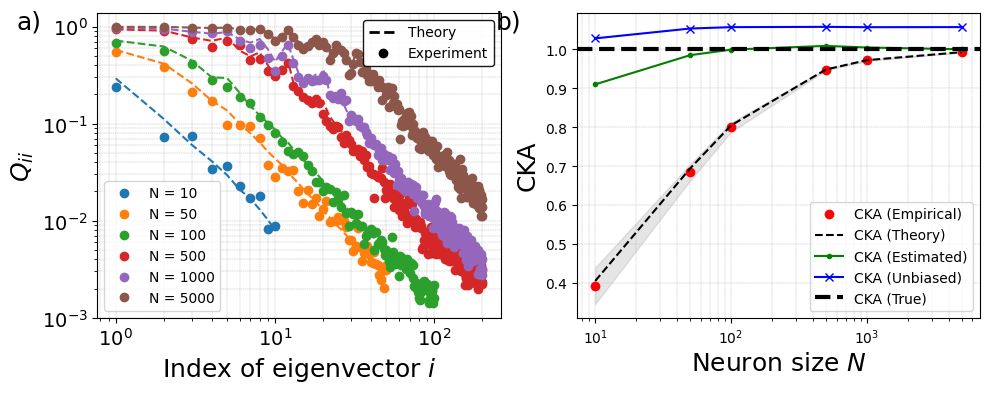

In [7]:
from matplotlib.lines import Line2D

keys = ['naive_cka_final', 'predicted_cka_final',
        'estimated_cka_final', 'moment_cka_est_mean',
        'cka_naive_mean', 'cka_naive_std',
        'Q_emp_mean', 'Q_emp_std', 'Q_th_mean', 'Q_th_std', 'Q_th_final']

total_data = {key: [] for key in keys}
for data in all_data:
    for key in keys:
        total_data[key] += [data[key]]
total_data = {key: np.asarray(total_data[key]) for key in keys}

P_idx = -1
skip = 1

label_fontsize = 18
tick_fontsize = 14

cka_mean = total_data['cka_naive_mean'].mean(-1)[P_idx]
cka_std = total_data['cka_naive_std'].mean(-1)[P_idx]
predicted_cka = total_data['predicted_cka_final'].mean(-1)[P_idx]
estimated_cka = total_data['estimated_cka_final'].mean(-1)[P_idx]
moment_cka_est_mean = total_data['moment_cka_est_mean'].mean(-1)[P_idx]
Q_emp_mean = total_data['Q_emp_mean'].mean(-1)
Q_th_mean = total_data['Q_th_mean'].mean(-1)
Q_th_avg = total_data['Q_th_final'].mean(-1)

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(10, 4))

# First subplot - CKA plot
ax1.semilogx(neuron_sizes, cka_mean, 'o', label='CKA (Empirical)', color='red')
ax1.fill_between(neuron_sizes, cka_mean - cka_std, cka_mean + cka_std, color='gray', alpha=0.2)

ax1.semilogx(neuron_sizes, predicted_cka, '--', label='CKA (Theory)', color='black')

ax1.semilogx(neuron_sizes, estimated_cka, '.-', label='CKA (Estimated)', color='green')

ax1.semilogx(neuron_sizes, moment_cka_est_mean[:, -1], 'x-', label='CKA (Unbiased)', color='blue')

ax1.axhline(y=1, color='black', linestyle='dashed', linewidth=3, label='CKA (True)')
ax1.set_xlabel(r"Neuron size $N$", fontsize=label_fontsize)
ax1.set_ylabel(r"CKA", fontsize=label_fontsize)
ax1.grid(True, which='both', linestyle='--', linewidth=0.3)
ax1.legend(loc='lower right', fontsize=10)

# Second subplot - Q diagonal elements
for i, idx in enumerate(range(0, len(neuron_sizes), skip)):
    Q_emp = Q_emp_mean[P_idx, idx, :, :]
    Q_th = Q_th_avg[P_idx, idx, :, :]
    N = neuron_sizes[idx]
    idxs = np.arange(1, len(Q_emp)+1)
    ax2.loglog(idxs[:N], np.diag(Q_emp)[:N], 'o', label=f'N = {N}', color=f'C{i}')
    ax2.loglog(idxs[:N], np.diag(Q_th)[:N], '--', color=f'C{i}')

linestyle_legend = [Line2D([0], [0], color='black', marker=None, linestyle='--', label=f"Theory", lw=2),
                    Line2D([0], [0], color='black', marker='o', linestyle="None", label=f"Experiment", lw=2)]
first_legend = ax2.legend(handles=linestyle_legend, loc='upper right', fontsize=10,
                          frameon=True, framealpha=0.9, edgecolor='black', fancybox=True)
ax2.add_artist(first_legend)
ax2.set_xlabel('Index of eigenvector $i$', fontsize=label_fontsize)
ax2.set_ylabel(r'$Q_{ii}$', fontsize=label_fontsize)
ax2.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax2.set_ylim([1e-3, None])
ax2.legend(fontsize=10)
ax2.grid(True, which='both', linestyle='--', linewidth=0.3)

plt.tight_layout()
ax1.text(-0.2, 0.95, 'b)', fontsize=18, transform=ax1.transAxes)
ax2.text(-0.2, 0.95, 'a)', fontsize=18, transform=ax2.transAxes)
# plt.savefig('./figures/overlap_and_cka_resnet18.pdf', bbox_inches='tight')
plt.show()

### Power law example


In [ ]:
def power_law_diag_matrix(size, exponent, device):
    diag_entries = torch.tensor([i**exponent for i in range(1, size+1)], device=device, dtype=torch.float64)
    diag_entries = diag_entries / torch.sum(diag_entries)
    diag_entries = diag_entries * size
    return torch.diag(diag_entries)


sample_sizes = np.logspace(1.61, 3, 3, dtype=int)
sample_sizes = [1000]
neuron_sizes = np.logspace(1.4, 2.5, 4, dtype=int)
num_trials = 3
num_iterations = 20
cutoff = None

act = torch.sqrt(power_law_diag_matrix(1000, -1.2, device=device))

use_real_neuron = False
override = False

all_data = experiment(act,
                      act,
                      sample_sizes,
                      neuron_sizes,
                      num_trials=num_trials,
                      num_iterations=num_iterations,
                      cutoff=cutoff,
                      use_real_neuron=use_real_neuron,
                      fn_prefix='overlap_power_law',
                      fn_suffix='',
                      override=override)

File ./results/overlap_power_law_1000_trials_3_iters_20.npz does not exist. Running the experiment...
P=1000, N1=1000, N2=1000, True CKA: 0.9999999999999998, True CCA: 1.0
Neuron_size=25/1000
334 5.541563119493276e-08
297 1.0696524554987263e-08
378 8.906326698365774e-08
325 1.4587426377943302e-08
324 6.216160208794008e-08
367 9.800933398196321e-09
260 5.0991378230946793e-08
289 2.43005828792775e-08
354 6.424480680777833e-08
366 8.397612916155595e-08
226 1.1828475976471964e-09
316 9.373462006578848e-10
259 8.909645110577458e-08
258 6.466389557147068e-08
303 2.433233525778178e-08
391 7.154858039370993e-08
289 1.904187740819907e-08
291 9.778773879531855e-08
341 9.792303323763463e-08
337 1.3589721348239436e-08
187 5.0358959224894306e-08
Neuron_size=58/1000
341 7.388041911582377e-08
339 6.662500773302327e-08
343 3.123103375912706e-08
324 3.285627059312901e-08
371 1.8232100273962715e-09
354 6.1575160970051e-08
284 7.249902989059365e-08
302 5.8624126886286376e-08
300 7.436949189809638e-08
350

/mnt/home/acanatar/jupyter/spectral_cka/NeurIPS_camera_ready/code/src/spectral_cka.py:181: RuntimeWarning: invalid value encountered in sqrt
  y = x1 / np.sqrt(x2 * x3)
/mnt/home/acanatar/jupyter/spectral_cka/NeurIPS_camera_ready/code/src/spectral_cka.py:182: RuntimeWarning: invalid value encountered in sqrt
  sigma_y = np.sqrt(term1 + term2 + term3)


278 8.504873250103628e-09
Neuron_size=316/1000
247 9.4431575448084e-08
390 2.2098067375964092e-08
271 4.5264528125699144e-08
472 2.758610673225803e-08
999 3.4551380590386316e-05
454 7.262133294716477e-08
257 6.162913024354566e-08
464 5.841465267053536e-08
999 0.0002631331023223993
288 3.142988180826478e-08
309 7.378317512518606e-08
346 8.69780922840846e-08
395 2.7250317558014103e-08
349 3.703280349043325e-08
436 2.2093121998523202e-08
364 5.629869637147067e-08
999 0.0010322299803311452
206 1.3226340911387524e-08
407 2.9966750858534397e-08
704 5.4979292229973e-08
272 3.714610752325598e-08
P=1000, N1=1000, N2=1000, True CKA: 0.9999999999999998, True CCA: 1.0
Neuron_size=25/1000
272 2.9560744962964236e-08
333 5.315215645396165e-08
394 3.125350289678863e-08
190 1.0482386514354403e-08
326 7.973055105026106e-08
269 4.834632516548254e-08
352 5.7981617729296886e-08
358 2.1263858229758625e-08
334 2.4274616094999146e-08
327 2.3953816707944497e-08
437 2.2803872568033512e-08
248 6.334264668339529e

In [ ]:
from matplotlib.lines import Line2D
keys = ['naive_cka_final', 'predicted_cka_final',
        'estimated_cka_final', 'moment_cka_est_mean',
        'cka_naive_mean', 'cka_naive_std',
        'Q_emp_mean', 'Q_emp_std', 'Q_th_mean', 'Q_th_std', 'Q_th_final']
total_data = {key: [] for key in keys}
for data in all_data:
    for key in keys:
        total_data[key] += [data[key]]
total_data = {key: np.asarray(total_data[key]) for key in keys}

P_idx = -1
skip = 1

cka_mean = total_data['cka_naive_mean'].mean(-1)[P_idx]
cka_std = total_data['cka_naive_std'].mean(-1)[P_idx]
predicted_cka = total_data['predicted_cka_final'].mean(-1)[P_idx]
estimated_cka = total_data['estimated_cka_final'].mean(-1)[P_idx]
moment_cka_est_mean = total_data['moment_cka_est_mean'].mean(-1)[P_idx]
Q_emp_mean = total_data['Q_emp_mean'].mean(-1)
Q_th_mean = total_data['Q_th_mean'].mean(-1)
Q_th_avg = total_data['Q_th_final'].mean(-1)

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(10, 4))

# First subplot - CKA plot
ax1.semilogx(neuron_sizes, cka_mean, 'o', label='CKA (Empirical)', color='red')
ax1.fill_between(neuron_sizes, cka_mean - cka_std, cka_mean + cka_std, color='gray', alpha=0.2)

ax1.semilogx(neuron_sizes, predicted_cka, '--', label='CKA (Theory)', color='black')

ax1.semilogx(neuron_sizes, estimated_cka, '.-', label='CKA (Estimated)', color='green')

ax1.semilogx(neuron_sizes, moment_cka_est_mean[:, -1], 'x-', label='CKA (Unbiased)', color='blue')

ax1.axhline(y=1, color='black', linestyle='dashed', linewidth=3, label='CKA (True)')
ax1.set_xlabel(r"Neuron size $N$", fontsize=label_fontsize)
ax1.set_ylabel(r"CKA", fontsize=label_fontsize)
ax1.grid(True, which='both', linestyle='--', linewidth=0.3)
ax1.legend(loc='lower right', fontsize=10)

# Second subplot - Q diagonal elements
for i, idx in enumerate(range(0, len(neuron_sizes), skip)):
    Q_emp = Q_emp_mean[P_idx, idx, :, :]
    Q_th = Q_th_avg[P_idx, idx, :, :]
    N = neuron_sizes[idx]
    idxs = np.arange(1, len(Q_emp)+1)
    ax2.loglog(idxs[:N], np.diag(Q_emp)[:N], 'o', label=f'N = {N}', color=f'C{i}')
    ax2.loglog(idxs[:N], np.diag(Q_th)[:N], '--', color=f'C{i}')

linestyle_legend = [Line2D([0], [0], color='black', marker=None, linestyle='--', label=f"Theory", lw=2),
                    Line2D([0], [0], color='black', marker='o', linestyle="None", label=f"Experiment", lw=2)]
first_legend = ax2.legend(handles=linestyle_legend, loc='upper right', fontsize=10,
                          frameon=True, framealpha=0.9, edgecolor='black', fancybox=True)
ax2.add_artist(first_legend)
ax2.set_xlabel('Index of eigenvector $i$', fontsize=label_fontsize)
ax2.set_ylabel(r'$Q_{ii}$', fontsize=label_fontsize)
ax2.set_ylim([1e-3, None])
ax2.legend(fontsize=10)
ax2.grid(True, which='both', linestyle='--', linewidth=0.3)

plt.tight_layout()
ax1.text(-0.15, 0.95, 'b)', fontsize=18, transform=ax1.transAxes)
ax2.text(-0.15, 0.95, 'a)', fontsize=18, transform=ax2.transAxes)
# plt.savefig('./figures/overlap_and_cka_powerlaw.pdf', bbox_inches='tight')
plt.show()